## Hierarchial methods

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pylab import rcParams
import seaborn as sns

import sklearn
import sklearn.metrics as sm

In [2]:
from sklearn.cluster import AgglomerativeClustering

import scipy
from scipy.cluster.hierarchy import dendrogram, linkage,fcluster, cophenet
from scipy.spatial.distance import pdist

In [3]:
np.set_printoptions(precision=4, suppress=True)
plt.figure(figsize=(10, 3))
%matplotlib inline
sns.set_style("whitegrid")

In [5]:
address = '../data/mtcars.csv'

cars = pd.read_csv(address)
cars.columns=['car_names', 'mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear', 'carb']

x= cars[['mpg', 'disp', 'hp', 'wt']].values

y= cars.iloc[:,(9)].values

### Using scipy to generate dendrograms

In [6]:
z = linkage(x, 'ward')

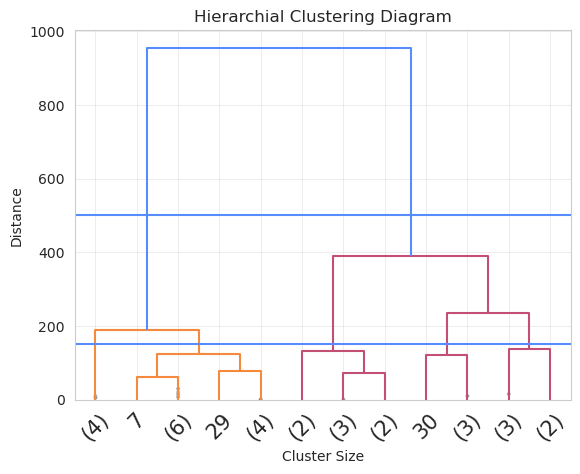

In [7]:
dendrogram(z,
           truncate_mode='lastp',
           p=12, leaf_rotation=45.,
           leaf_font_size=15.,
           show_contracted=True)

plt.title('Hierarchial Clustering Diagram')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')

plt.axhline(y=500)
plt.axhline(y=150)
plt.show()

### Generating hierarchical clusters

### metric as euclidean and linkage as ward

In [9]:
k=2

Hclustering = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')

Hclustering.fit(x)

sm.accuracy_score(y, Hclustering.labels_)

0.78125

### metric as manhattan and linkage as average

In [10]:
k=2

Hclustering = AgglomerativeClustering(n_clusters=k, metric='manhattan', linkage='average')

Hclustering.fit(x)

sm.accuracy_score(y, Hclustering.labels_)

0.71875